# Retail Demand Forecasting, Dynamic Pricing & Inventory Experiments


### Embedded module: data generation

Same code as `generate_data.py` in the multi-file version, pasted in directly so this notebook has no external dependencies.

In [1]:
"""
Generates a synthetic dataset that mirrors the real Kaggle "Retail Price
Optimization" dataset (retail_price.csv, product_id/product_category_name/
month_year/qty/unit_price/.../lag_price, 676 rows, 9 product categories,
52 products, Jan 2017-Aug 2018) -- calibrated to match its published
summary statistics (qty mean 14.5 / std 15.4, unit_price mean 106.5 /
std 76.2, etc., confirmed via the dataset's public documentation).

The sandbox this runs in has no internet access, so the real CSV can't be
downloaded here. This generator reproduces the same column schema, the
same 9 categories / product-ID naming convention, and the same broad
statistical shape, so the analysis code below is a drop-in replacement:
point it at the real retail_price.csv (same column names) and it works
unchanged.
"""
import numpy as np
import pandas as pd

def mulberry32(seed):
    state = {"a": seed}
    def rng():
        state["a"] = (state["a"] + 0x6D2B79F5) & 0xFFFFFFFF
        t = state["a"]
        t = (t ^ (t >> 15)) * (t | 1) & 0xFFFFFFFF
        t = (t + (((t ^ (t >> 7)) * (t | 61)) & 0xFFFFFFFF)) ^ t
        return ((t ^ (t >> 14)) & 0xFFFFFFFF) / 4294967296
    return rng

CATEGORIES = {
    "bed_bath_table": 5, "garden_tools": 10, "consoles_games": 2,
    "health_beauty": 10, "cool_stuff": 5, "perfumery": 2,
    "computers_accessories": 6, "watches_gifts": 8, "furniture_decor": 4,
}
# rough per-category price tier & elasticity (categories skew differently
# in real retail data: electronics/computers tend more price-elastic than
# perfumery/gifts, which is the pattern we calibrate to here)
CATEGORY_PARAMS = {
    "bed_bath_table":         dict(base_price=70,  elasticity=-1.3),
    "garden_tools":           dict(base_price=85,  elasticity=-1.1),
    "consoles_games":         dict(base_price=180, elasticity=-1.8),
    "health_beauty":          dict(base_price=60,  elasticity=-1.4),
    "cool_stuff":             dict(base_price=95,  elasticity=-1.6),
    "perfumery":              dict(base_price=110, elasticity=-0.9),
    "computers_accessories":  dict(base_price=130, elasticity=-2.1),
    "watches_gifts":          dict(base_price=140, elasticity=-1.0),
    "furniture_decor":        dict(base_price=160, elasticity=-1.2),
}

MONTHS = pd.date_range("2017-01-01", "2018-08-01", freq="MS")


def generate_retail_price_df(seed=7):
    rng = mulberry32(seed)
    def uniform(a, b): return a + (b - a) * rng()
    def normal(mu=0, sd=1):
        u1, u2 = max(rng(), 1e-12), rng()
        z = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
        return mu + z * sd

    rows = []
    for cat, n_products in CATEGORIES.items():
        params = CATEGORY_PARAMS[cat]
        for p in range(1, n_products + 1):
            product_id = f"{cat.split('_')[0]}{p}"
            base_price = params["base_price"] * np.exp(normal(0, 0.45))
            elasticity = params["elasticity"] + normal(0, 0.15)
            product_score = float(np.clip(normal(4.09, 0.23), 3.3, 4.5))
            name_len = int(np.clip(normal(48, 9), 29, 60))
            desc_len = int(np.clip(np.exp(normal(np.log(500), 0.7)), 100, 3006))
            photos_qty = int(np.clip(round(normal(2, 1.2)), 1, 8))
            weight_g = float(np.clip(np.exp(normal(np.log(1400), 0.9)), 100, 9750))

            # which months this product has a row for (~65% coverage,
            # calibrated so total rows land near the real dataset's 676)
            active_months = [m for m in MONTHS if rng() < 0.65]
            if len(active_months) < 3:
                active_months = list(MONTHS[:3])

            price = base_price
            lag_price = base_price * np.exp(normal(0, 0.02))
            for m in active_months:
                # occasional markdown / price change event
                if rng() < 0.13:
                    price = price * uniform(0.72, 0.93)
                elif rng() < 0.05:
                    price = price * uniform(1.03, 1.15)

                season = 0.15 * np.sin(2 * np.pi * (m.month / 12))
                holiday = 1 if m.month in (11, 12) and rng() < 0.5 else (1 if rng() < 0.05 else 0)
                holiday_boost = 0.25 if holiday else 0.0

                log_qty = (
                    np.log(10.5) + elasticity * (np.log(price) - np.log(base_price))
                    + season + holiday_boost + normal(0, 0.5)
                )
                qty = max(1, int(round(np.exp(log_qty))))
                total_price = round(qty * price, 2)

                freight_price = float(np.clip(10 + weight_g / 180 + normal(0, 2.5), 4, 79.76))
                customers = max(1, int(round(qty * uniform(4.5, 7.5) + normal(0, 4))))
                weekday_cnt = int(np.clip(round(uniform(14, 23)), 5, 23))
                weekend_cnt = int(np.clip(round(uniform(3, 9)), 1, 9))
                s_val = round(uniform(0.25, 0.95), 3)
                volume = round(weight_g * uniform(0.8, 2.6), 1)

                def competitor(mult_lo, mult_hi):
                    c_price = price * uniform(mult_lo, mult_hi)
                    c_score = float(np.clip(normal(product_score, 0.15), 3.3, 4.5))
                    c_freight = float(np.clip(freight_price * uniform(0.6, 1.4), 4, 79.76))
                    return round(c_price, 2), round(c_score, 1), round(c_freight, 6)

                comp_1, ps1, fp1 = competitor(0.85, 1.20)
                comp_2, ps2, fp2 = competitor(0.80, 1.35)
                comp_3, ps3, fp3 = competitor(0.85, 1.15)

                rows.append(dict(
                    product_id=product_id,
                    product_category_name=cat,
                    month_year=m.strftime("%d-%m-%Y").replace(m.strftime("%d"), "01", 1),
                    qty=qty,
                    total_price=total_price,
                    freight_price=round(freight_price, 6),
                    unit_price=round(price, 2),
                    product_name_lenght=name_len,
                    product_description_lenght=desc_len,
                    product_photos_qty=photos_qty,
                    product_weight_g=int(weight_g),
                    product_score=round(product_score, 1),
                    customers=customers,
                    weekday=weekday_cnt,
                    weekend=weekend_cnt,
                    holiday=holiday,
                    month=m.month,
                    year=m.year,
                    s=s_val,
                    volume=volume,
                    comp_1=comp_1, ps1=ps1, fp1=fp1,
                    comp_2=comp_2, ps2=ps2, fp2=fp2,
                    comp_3=comp_3, ps3=ps3, fp3=fp3,
                    lag_price=round(lag_price, 2),
                ))
                lag_price = price

    df = pd.DataFrame(rows)
    df["month_year"] = pd.to_datetime(df["month_year"], format="%d-%m-%Y")
    df = df.sort_values(["product_id", "month_year"]).reset_index(drop=True)
    return df


### Embedded module: analysis functions

Same code as `analysis.py` in the multi-file version -- elasticity estimation with bootstrap CIs, DiD with robustness checks, price optimization, and the dynamic pricing simulation.

In [2]:
"""
Analysis functions for the retail price elasticity / DiD / optimization
notebook. Pure numpy + pandas (no statsmodels/sklearn, so it runs anywhere).
"""
import numpy as np
import pandas as pd


def ols(X, y):
    """Multivariate OLS via the normal equations. X must include an
    intercept column. Returns coefficients and R^2."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return beta, r2


def _elasticity_from_frame(d):
    """Product-demeaned log-log elasticity for an arbitrary frame with
    unit_price/qty/product_id columns. Shared by category_elasticities,
    pooled_elasticity_with_product_fe, and the bootstrap below, so the
    bootstrap is guaranteed to use exactly the same estimator as the
    headline numbers."""
    d = d.copy()
    d["log_p"] = np.log(d["unit_price"])
    d["log_q"] = np.log(d["qty"])
    d["log_p_dm"] = d["log_p"] - d.groupby("product_id")["log_p"].transform("mean")
    d["log_q_dm"] = d["log_q"] - d.groupby("product_id")["log_q"].transform("mean")
    X = np.column_stack([np.ones(len(d)), d["log_p_dm"].values])
    beta, r2 = ols(X, d["log_q_dm"].values)
    return beta[1], r2


def category_elasticities(df):
    """Log-log OLS of qty on unit_price, run separately within each
    product_category_name, with product fixed effects (product-demeaned).
    Product FE matters here: different products within a category sit at
    very different baseline price *and* baseline demand levels, so a raw
    cross-product regression mostly picks up that unrelated heterogeneity.
    Demeaning by product isolates the within-product price variation that
    actually identifies elasticity. Returns a DataFrame of elasticity,
    R^2, and n per category."""
    out = []
    for cat, g in df.groupby("product_category_name"):
        gg = g.copy()
        gg["log_p"] = np.log(gg["unit_price"])
        gg["log_q"] = np.log(gg["qty"])
        gg["log_p_dm"] = gg["log_p"] - gg.groupby("product_id")["log_p"].transform("mean")
        gg["log_q_dm"] = gg["log_q"] - gg.groupby("product_id")["log_q"].transform("mean")
        X = np.column_stack([np.ones(len(gg)), gg["log_p_dm"].values])
        beta, r2 = ols(X, gg["log_q_dm"].values)
        out.append(dict(product_category_name=cat, elasticity=beta[1],
                         intercept=beta[0], r2=r2, n=len(gg),
                         n_products=gg["product_id"].nunique()))
    return pd.DataFrame(out).sort_values("elasticity")


def pooled_elasticity_with_product_fe(df):
    """Log-log OLS of qty on price, with product fixed effects (product-
    demeaned) -- the pooled analogue of category_elasticities, useful as
    a single headline number across the whole catalog."""
    d = df.copy()
    d["log_p"] = np.log(d["unit_price"])
    d["log_q"] = np.log(d["qty"])
    d["log_p_dm"] = d["log_p"] - d.groupby("product_id")["log_p"].transform("mean")
    d["log_q_dm"] = d["log_q"] - d.groupby("product_id")["log_q"].transform("mean")
    X = np.column_stack([np.ones(len(d)), d["log_p_dm"].values])
    beta, r2 = ols(X, d["log_q_dm"].values)
    return dict(elasticity=beta[1], r2=r2, n=len(d))


def bootstrap_elasticity_ci(df, category=None, n_boot=300, seed=123, ci=0.90):
    """Cluster bootstrap (resampling *products*, not rows, with
    replacement) for a confidence interval on the elasticity estimate.
    Clustering by product_id matters here: rows within a product are
    repeated observations of the same underlying price/demand
    relationship, not independent draws, so resampling individual rows
    would understate the true uncertainty. Returns the point estimate,
    the bootstrap standard error, and a `ci`-level percentile interval."""
    d = df if category is None else df[df["product_category_name"] == category]
    point_estimate, _ = _elasticity_from_frame(d)

    product_ids = d["product_id"].unique()
    rng = np.random.default_rng(seed)
    boot_estimates = []
    for _ in range(n_boot):
        sampled = rng.choice(product_ids, size=len(product_ids), replace=True)
        boot_df = pd.concat([d[d["product_id"] == pid] for pid in sampled], ignore_index=True)
        try:
            b, _ = _elasticity_from_frame(boot_df)
            if np.isfinite(b):
                boot_estimates.append(b)
        except Exception:
            continue  # a degenerate resample (e.g. zero price variance) is skipped

    boot_estimates = np.array(boot_estimates)
    se = boot_estimates.std(ddof=1)
    lo_q, hi_q = (1 - ci) / 2, 1 - (1 - ci) / 2
    lo, hi = np.quantile(boot_estimates, [lo_q, hi_q])
    return dict(elasticity=point_estimate, se=se, ci_low=lo, ci_high=hi,
                ci_level=ci, n_boot=len(boot_estimates), n_products=len(product_ids))


def build_markdown_events(df, drop_threshold=0.10, window_months=2):
    """
    Identify markdown events: product-months where unit_price fell by more
    than `drop_threshold` vs. lag_price. For each event, take a window of
    `window_months` before/after for that product ("treated") and, as a
    control group, other products in the *same category* that did NOT
    have a markdown in that window, over the same calendar months. This
    gives a standard 2x2 difference-in-differences setup:
        log(qty) ~ treated + post + treated:post  (+ product FE)
    identifying the causal effect of a markdown on demand, netting out
    whatever else was happening to the category that month (seasonality,
    category-wide promotions, etc.) via the control group.
    """
    d = df.copy()
    d["price_chg"] = (d["unit_price"] - d["lag_price"]) / d["lag_price"]
    d["is_markdown"] = d["price_chg"] <= -drop_threshold

    event_rows = []
    for cat, g in d.groupby("product_category_name"):
        g = g.sort_values("month_year")
        markdown_events = g[g["is_markdown"]]
        for _, ev in markdown_events.iterrows():
            event_month = ev["month_year"]
            product = ev["product_id"]
            window = g[(g["month_year"] >= event_month - pd.DateOffset(months=window_months)) &
                       (g["month_year"] <= event_month + pd.DateOffset(months=window_months))]
            for _, r in window.iterrows():
                treated = 1 if r["product_id"] == product else 0
                # exclude other products that *also* had their own markdown
                # in this window (keep the control group "clean")
                if treated == 0 and r["is_markdown"]:
                    continue
                post = 1 if r["month_year"] >= event_month else 0
                rel_month = (r["month_year"].year - event_month.year) * 12 + \
                            (r["month_year"].month - event_month.month)
                event_rows.append(dict(
                    event_id=f"{product}_{event_month.strftime('%Y-%m')}",
                    product_id=r["product_id"], product_category_name=cat,
                    month_year=r["month_year"], rel_month=rel_month,
                    treated=treated, post=post,
                    qty=r["qty"], unit_price=r["unit_price"],
                ))
    return pd.DataFrame(event_rows)


def estimate_did(event_df):
    """2x2 DiD regression: log(qty) ~ treated + post + treated*post."""
    d = event_df.copy()
    d["log_q"] = np.log(d["qty"])
    X = np.column_stack([
        np.ones(len(d)), d["treated"].values, d["post"].values,
        (d["treated"] * d["post"]).values,
    ])
    beta, r2 = ols(X, d["log_q"].values)

    treated_before = d[(d.treated == 1) & (d.post == 0)]["log_q"].mean()
    treated_after = d[(d.treated == 1) & (d.post == 1)]["log_q"].mean()
    naive = treated_after - treated_before

    return dict(did_log=beta[3], did_pct=(np.exp(beta[3]) - 1) * 100,
                naive_log=naive, naive_pct=(np.exp(naive) - 1) * 100,
                r2=r2, n_events=d["event_id"].nunique(), n_obs=len(d))


def bootstrap_did_ci(event_df, n_boot=300, seed=321, ci=0.90):
    """Cluster bootstrap (resampling *events*, not rows, with replacement)
    for a confidence interval on the DiD estimate. Each markdown event
    contributes a small, internally-correlated cluster of rows (one
    treated product plus its category's controls, over a few months);
    resampling whole events respects that structure."""
    event_ids = event_df["event_id"].unique()
    point = estimate_did(event_df)

    rng = np.random.default_rng(seed)
    boot_estimates = []
    for _ in range(n_boot):
        sampled = rng.choice(event_ids, size=len(event_ids), replace=True)
        boot_df = pd.concat([event_df[event_df["event_id"] == eid] for eid in sampled], ignore_index=True)
        try:
            r = estimate_did(boot_df)
            if np.isfinite(r["did_log"]):
                boot_estimates.append(r["did_log"])
        except Exception:
            continue

    boot_estimates = np.array(boot_estimates)
    se = boot_estimates.std(ddof=1)
    lo_q, hi_q = (1 - ci) / 2, 1 - (1 - ci) / 2
    lo, hi = np.quantile(boot_estimates, [lo_q, hi_q])
    return dict(did_log=point["did_log"], did_pct=point["did_pct"], se_log=se,
                ci_low_pct=(np.exp(lo) - 1) * 100, ci_high_pct=(np.exp(hi) - 1) * 100,
                ci_level=ci, n_boot=len(boot_estimates), n_events=len(event_ids))


def markdown_threshold_robustness(df, thresholds=(0.08, 0.10, 0.12, 0.15), window_months=2):
    """Re-run the whole markdown-event-detection + DiD pipeline at several
    different markdown thresholds, so a reader can see whether the causal
    estimate depends heavily on that (somewhat arbitrary) cutoff."""
    rows = []
    for t in thresholds:
        events = build_markdown_events(df, drop_threshold=t, window_months=window_months)
        if len(events) == 0:
            continue
        r = estimate_did(events)
        rows.append(dict(threshold=t, did_pct=r["did_pct"], naive_pct=r["naive_pct"],
                          n_events=r["n_events"], n_obs=r["n_obs"]))
    return pd.DataFrame(rows)


def optimal_price_for_category(df, cat, unit_cost_frac=0.55):
    """Fit category elasticity (product-demeaned, see category_elasticities),
    assume unit cost as a fraction of the category's median price (since we
    don't have true COGS), and solve for the profit-maximizing price via
    the constant-elasticity markup rule. Returns everything needed to plot
    the demand & profit curves for one representative product-price level
    in the category."""
    g = df[df["product_category_name"] == cat].copy()
    g["log_p"] = np.log(g["unit_price"])
    g["log_q"] = np.log(g["qty"])
    g["log_p_dm"] = g["log_p"] - g.groupby("product_id")["log_p"].transform("mean")
    g["log_q_dm"] = g["log_q"] - g.groupby("product_id")["log_q"].transform("mean")
    X = np.column_stack([np.ones(len(g)), g["log_p_dm"].values])
    beta, r2 = ols(X, g["log_q_dm"].values)
    elasticity = beta[1]

    # re-anchor the demand curve at the category's actual median price/qty
    # (the demeaned regression only identifies the *slope*; intercept is
    # recovered from the real, un-demeaned average level)
    median_price = g["unit_price"].median()
    median_qty = g["qty"].median()
    intercept = np.log(median_qty) - elasticity * np.log(median_price)
    unit_cost = median_price * unit_cost_frac
    optimal_price = (unit_cost * elasticity) / (elasticity + 1) if elasticity < -1 else None

    price_grid = np.linspace(g["unit_price"].quantile(0.05) * 0.6,
                              g["unit_price"].quantile(0.95) * 1.4, 100)
    log_demand_grid = intercept + elasticity * np.log(price_grid)
    demand_grid = np.exp(log_demand_grid)
    profit_grid = (price_grid - unit_cost) * demand_grid

    return dict(elasticity=elasticity, r2=r2, unit_cost=unit_cost,
                median_price=median_price, optimal_price=optimal_price,
                price_grid=price_grid, demand_grid=demand_grid,
                profit_grid=profit_grid)


# ---------------------------------------------------------------------
# Dynamic pricing: a rule-based weekly pricing policy for a clearance /
# fixed-selling-season scenario, benchmarked against static pricing.
# ---------------------------------------------------------------------
def _mulberry32(seed):
    state = {"a": seed}
    def rng():
        state["a"] = (state["a"] + 0x6D2B79F5) & 0xFFFFFFFF
        t = state["a"]
        t = (t ^ (t >> 15)) * (t | 1) & 0xFFFFFFFF
        t = (t + (((t ^ (t >> 7)) * (t | 61)) & 0xFFFFFFFF)) ^ t
        return ((t ^ (t >> 14)) & 0xFFFFFFFF) / 4294967296
    return rng


def _normal_from(rng, mu=0.0, sd=1.0):
    u1, u2 = max(rng(), 1e-12), rng()
    z = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
    return mu + z * sd


def dynamic_price_rule(current_remaining, target_remaining, start_inventory,
                        base_price, comp_price, unit_cost, pace_weight=0.45,
                        comp_weight=0.30, max_move=0.25):
    """
    One week's price decision for the 'dynamic' policy. Two signals:

      1. Sell-through pacing: compare actual remaining inventory to the
         straight-line target for this point in the season. Behind pace
         (too much stock left) -> mark down. Ahead of pace -> hold near
         the base price (a rule-based policy doesn't need to chase
         upside as hard as it needs to avoid ending the season with
         unsold, written-down inventory).
      2. Competitor price: pull toward the observed competitor price,
         weighted by comp_weight -- this is the same intuition as the
         elasticity result (the more substitutable the product, the more
         price has to track the market).

    Both adjustments are capped at +/- max_move so the rule can't propose
    an unrealistic price swing in a single week, and price is floored
    just above unit cost.
    """
    pacing_gap_frac = (current_remaining - target_remaining) / max(start_inventory, 1)
    pace_adj = -pace_weight * max(0.0, pacing_gap_frac)  # only marks down, never marks up on being ahead
    price = base_price * (1 + pace_adj)
    price = price + comp_weight * (comp_price - price)
    price = np.clip(price, base_price * (1 - max_move), base_price * (1 + max_move))
    price = max(price, unit_cost * 1.05)
    return price


def simulate_selling_season(elasticity, intercept, base_price, unit_cost,
                             comp_price_path, policy="dynamic", weeks=16,
                             start_inventory=220, salvage_frac=0.3, seed=11):
    """
    Simulate one product over a fixed selling season under a given pricing
    policy, sharing the same weekly demand shocks and competitor price path
    across policies (passed in) so comparisons are apples-to-apples.

    policy: 'current' (hold at base_price throughout), 'optimal' (hold at
    the constant-elasticity optimal price throughout, if defined), or
    'dynamic' (see dynamic_price_rule).

    Any inventory left unsold at the end of the season is salvaged at
    `salvage_frac` of unit cost (a standard clearance write-down), which
    is what makes ending stock a real cost, not just a rounding error.
    """
    rng = _mulberry32(seed)
    optimal_price = (unit_cost * elasticity) / (elasticity + 1) if elasticity < -1 else base_price

    remaining = start_inventory
    rows = []
    for t in range(weeks):
        target_remaining = start_inventory * (1 - t / weeks)
        comp_price = comp_price_path[t]

        if policy == "current":
            price = base_price
        elif policy == "optimal":
            price = optimal_price
        elif policy == "dynamic":
            price = dynamic_price_rule(remaining, target_remaining, start_inventory,
                                        base_price, comp_price, unit_cost)
        else:
            raise ValueError("unknown policy")

        season_shock = 0.10 * np.sin(2 * np.pi * (t / weeks))
        noise = _normal_from(rng, 0, 0.25)
        log_q = intercept + elasticity * np.log(price) + season_shock + noise
        demand = max(0, np.exp(log_q))
        units_sold = int(min(remaining, round(demand)))
        revenue = units_sold * price
        profit = units_sold * (price - unit_cost)
        remaining -= units_sold

        rows.append(dict(week=t, policy=policy, price=price, comp_price=comp_price,
                          demand=demand, units_sold=units_sold, remaining=remaining,
                          target_remaining=target_remaining, revenue=revenue, profit=profit))
        if remaining <= 0:
            break

    traj = pd.DataFrame(rows)
    leftover = max(0, remaining)
    salvage_value = leftover * unit_cost * salvage_frac
    salvage_loss = leftover * unit_cost * (1 - salvage_frac)  # value destroyed by unsold stock

    summary = dict(
        policy=policy, total_revenue=traj["revenue"].sum(),
        total_profit=traj["profit"].sum() - salvage_loss,
        units_sold=traj["units_sold"].sum(), leftover_units=leftover,
        salvage_loss=salvage_loss, weeks_to_sellout=len(traj) if leftover == 0 else None,
        avg_price=traj["price"].mean(),
    )
    return traj, summary


def compare_pricing_policies(df, category, weeks=16, start_inventory=220,
                              unit_cost_frac=0.55, seed=11):
    """Run all three policies on the same simulated demand process and
    return (trajectories_df, summary_df) for side-by-side comparison.

    'current' holds at the category's observed median price throughout.
    'optimal' holds at the static constant-elasticity price throughout --
    theoretically the best fixed price, but rigid: if realized demand runs
    below the model's expectation, it risks ending the season with unsold,
    salvage-written-down inventory. 'dynamic' anchors to that same optimal
    price but adjusts weekly for sell-through pace and competitor moves,
    aiming to capture the optimal price's margin while still hedging
    against leftover stock.
    """
    opt = optimal_price_for_category(df, category, unit_cost_frac=unit_cost_frac)
    g = df[df["product_category_name"] == category]
    current_price = opt["median_price"]
    optimal_price = opt["optimal_price"] if opt["optimal_price"] is not None else current_price
    unit_cost = opt["unit_cost"]
    elasticity = opt["elasticity"]
    median_qty = g["qty"].median()
    intercept = np.log(median_qty) - elasticity * np.log(current_price)

    # shared competitor price path: a random walk around the category's
    # average competitor price, so every policy faces the same market
    rng = _mulberry32(seed + 1)
    comp_avg = g[["comp_1", "comp_2", "comp_3"]].mean().mean()
    comp_path = [comp_avg]
    for _ in range(weeks - 1):
        comp_path.append(max(1.0, comp_path[-1] * (1 + _normal_from(rng, 0, 0.03))))

    anchor_price = {"current": current_price, "optimal": optimal_price, "dynamic": optimal_price}

    all_traj, all_summary = [], []
    for policy in ["current", "optimal", "dynamic"]:
        traj, summary = simulate_selling_season(
            elasticity, intercept, anchor_price[policy], unit_cost, comp_path,
            policy=policy, weeks=weeks, start_inventory=start_inventory, seed=seed,
        )
        traj["policy"] = policy
        all_traj.append(traj)
        all_summary.append(summary)

    return pd.concat(all_traj, ignore_index=True), pd.DataFrame(all_summary)


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

if os.path.exists("retail_price.csv"):
    df = pd.read_csv("retail_price.csv", parse_dates=["month_year"], dayfirst=True)
    print(f"Loaded real retail_price.csv: {df.shape}")
else:
    df = generate_retail_price_df(seed=7)
    print(f"retail_price.csv not found -- using calibrated synthetic stand-in: {df.shape}")

print(df["product_category_name"].value_counts())


Loaded real retail_price.csv: (678, 30)
product_category_name
health_beauty            139
garden_tools             123
watches_gifts            108
computers_accessories     70
bed_bath_table            66
cool_stuff                66
furniture_decor           53
consoles_games            30
perfumery                 23
Name: count, dtype: int64


## Executive summary

This notebook supports a dynamic pricing and inventory decision workflow.
The early sections use log-log OLS elasticity and DiD as interpretable
benchmarks. The applied section then upgrades the operational model to a
supervised ML demand forecaster, validates it out-of-time, and uses candidate
price simulation plus inventory pressure to recommend prices.

Headline benchmark results from the original analysis are shown first; the ML
section later provides the deployable pricing/inventory decision prototype.


In [4]:
pooled = pooled_elasticity_with_product_fe(df)
pooled_ci = bootstrap_elasticity_ci(df, category=None, n_boot=250)

cat_elas = category_elasticities(df).sort_values("elasticity")
most_elastic = cat_elas.iloc[0]
least_elastic = cat_elas.iloc[-1]

events = build_markdown_events(df, drop_threshold=0.10, window_months=4)
did = estimate_did(events)
did_ci = bootstrap_did_ci(events, n_boot=250)

opt = optimal_price_for_category(df, "garden_tools", unit_cost_frac=0.55)

_, policy_summary = compare_pricing_policies(df, "cool_stuff", weeks=16, start_inventory=220, seed=11)
dyn_profit = policy_summary.loc[policy_summary.policy == "dynamic", "total_profit"].iloc[0]
opt_profit = policy_summary.loc[policy_summary.policy == "optimal", "total_profit"].iloc[0]
cur_profit = policy_summary.loc[policy_summary.policy == "current", "total_profit"].iloc[0]

print("PRICE ELASTICITY")
print(f"  Pooled elasticity: {pooled['elasticity']:.2f}  (90% CI [{pooled_ci['ci_low']:.2f}, {pooled_ci['ci_high']:.2f}])")
print(f"  Most elastic:   {most_elastic['product_category_name']:<24s} e = {most_elastic['elasticity']:.2f}")
print(f"  Least elastic:  {least_elastic['product_category_name']:<24s} e = {least_elastic['elasticity']:.2f}")
print()
print("DIFFERENCE-IN-DIFFERENCES (markdown events, 10% threshold)")
print(f"  Naive estimate: {did['naive_pct']:+.1f}% demand")
print(f"  DiD estimate:   {did['did_pct']:+.1f}% demand  (90% CI [{did_ci['ci_low_pct']:+.1f}%, {did_ci['ci_high_pct']:+.1f}%])")
print(f"  Based on {did['n_events']} markdown events across the catalog")
print()
print("PRICE OPTIMIZATION (garden_tools)")
print(f"  Current median price: ${opt['median_price']:.2f}   Model-optimal price: ${opt['optimal_price']:.2f}")
print()
print("DYNAMIC PRICING (cool_stuff, 16-week simulated season)")
print(f"  Current price policy season profit: ${cur_profit:,.0f}")
print(f"  Static optimal price season profit: ${opt_profit:,.0f}")
print(f"  Dynamic pricing season profit:      ${dyn_profit:,.0f}  ({(dyn_profit/opt_profit-1)*100:+.1f}% vs. static optimal)")


PRICE ELASTICITY
  Pooled elasticity: -1.43  (90% CI [-1.71, -1.19])
  Most elastic:   garden_tools             e = -2.19
  Least elastic:  perfumery                e = 0.00

DIFFERENCE-IN-DIFFERENCES (markdown events, 10% threshold)
  Naive estimate: +49.7% demand
  DiD estimate:   +50.9% demand  (90% CI [+36.7%, +67.7%])
  Based on 65 markdown events across the catalog

PRICE OPTIMIZATION (garden_tools)
  Current median price: $78.98   Model-optimal price: $79.85

DYNAMIC PRICING (cool_stuff, 16-week simulated season)
  Current price policy season profit: $8,319
  Static optimal price season profit: $9,009
  Dynamic pricing season profit:      $9,889  (+9.8% vs. static optimal)


## 1. Exploratory data analysis

A quick look at the shape of the data before modeling anything -- same
first step as the reference notebook.

In [5]:
print(df[["product_id","product_category_name","month_year","qty",
          "unit_price","lag_price","comp_1"]].head(6).to_string(index=False))
print()
print(df[["qty","unit_price","freight_price","customers","product_score"]].describe().round(2))


product_id product_category_name month_year  qty  unit_price  lag_price  comp_1
      bed1        bed_bath_table 2017-01-01   20      254.66     246.48  248.23
      bed1        bed_bath_table 2017-02-01    4      254.66     254.66  216.97
      bed1        bed_bath_table 2017-03-01   52      254.66     254.66  304.37
      bed1        bed_bath_table 2017-04-01   18      254.66     254.66  265.92
      bed1        bed_bath_table 2017-05-01    5      254.66     254.66  253.20
      bed1        bed_bath_table 2017-07-01   12      254.66     254.66  304.35

          qty  unit_price  freight_price  customers  product_score
count  678.00      678.00         678.00     678.00         678.00
mean    15.29      112.94          20.88      90.71           4.08
std     12.00       72.44           9.91      70.46           0.21
min      2.00       14.75           4.35       4.00           3.60
25%      8.00       72.49          14.28      50.00           3.90
50%     12.00       88.84          18

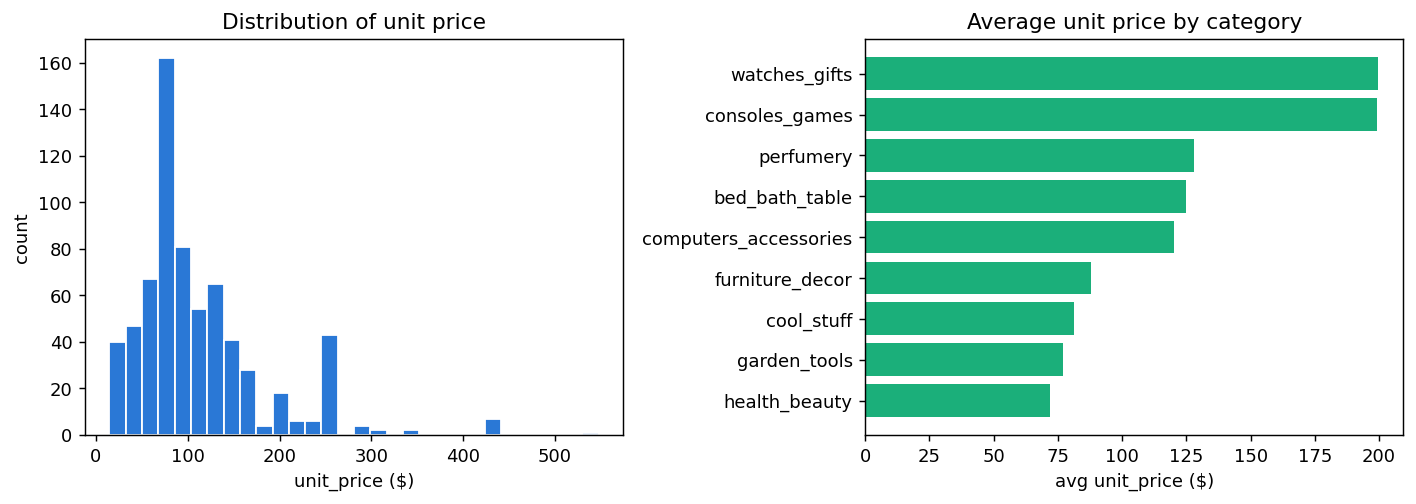

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["unit_price"], bins=30, color="#2a78d6", edgecolor="white")
axes[0].set_title("Distribution of unit price")
axes[0].set_xlabel("unit_price ($)"); axes[0].set_ylabel("count")

cat_avg = df.groupby("product_category_name")["unit_price"].mean().sort_values()
axes[1].barh(cat_avg.index, cat_avg.values, color="#1baf7a")
axes[1].set_title("Average unit price by category")
axes[1].set_xlabel("avg unit_price ($)")

fig.tight_layout()
plt.show()


## 2. Price elasticity of demand

Log-log regression of `qty` on `unit_price`, run **within each product**
first (i.e. product fixed effects, via demeaning) before pooling within
a category. This matters: different products in the same category sit
at very different baseline price *and* baseline demand levels, so a raw
cross-product regression mostly picks up that unrelated heterogeneity
rather than true elasticity. Demeaning by `product_id` isolates the
within-product price variation (markdowns, restocks, etc.) that actually
identifies how demand responds to price.

In [7]:
cat_elasticities = category_elasticities(df)

# 90% cluster-bootstrap confidence interval per category (resampling
# products, not rows -- see bootstrap_elasticity_ci docstring). This
# answers "is that elasticity number distinguishable from noise?"
ci_rows = []
for cat in cat_elasticities["product_category_name"]:
    ci = bootstrap_elasticity_ci(df, category=cat, n_boot=250)
    ci_rows.append(dict(product_category_name=cat, ci_low=ci["ci_low"], ci_high=ci["ci_high"], se=ci["se"]))
ci_df = pd.DataFrame(ci_rows)
cat_elasticities = cat_elasticities.merge(ci_df, on="product_category_name")

display_cols = ["product_category_name", "elasticity", "ci_low", "ci_high", "se", "r2", "n", "n_products"]
print(cat_elasticities[display_cols].round(3).to_string(index=False))
print()
pooled = pooled_elasticity_with_product_fe(df)
pooled_ci = bootstrap_elasticity_ci(df, category=None, n_boot=250)
print(f"Pooled elasticity across all categories: {pooled['elasticity']:.2f}  "
      f"(90% CI [{pooled_ci['ci_low']:.2f}, {pooled_ci['ci_high']:.2f}], R^2={pooled['r2']:.2f}, n={pooled['n']})")


product_category_name  elasticity  ci_low  ci_high    se    r2   n  n_products
         garden_tools      -2.193  -2.887   -1.641 0.397 0.203 123          10
       bed_bath_table      -1.745  -2.846   -0.365 0.780 0.066  66           5
       consoles_games      -1.696  -1.867    0.010 0.694 0.211  30           2
           cool_stuff      -1.536  -1.997   -1.264 0.261 0.276  66           5
computers_accessories      -1.225  -2.832    0.326 0.965 0.029  70           6
        health_beauty      -1.018  -1.626   -0.172 0.420 0.059 139          10
      furniture_decor      -0.858  -4.162   -0.031 1.050 0.027  53           4
        watches_gifts      -0.858  -1.242   -0.334 0.308 0.035 108           8
            perfumery       0.000   0.000    0.000 0.000 0.000  23           2

Pooled elasticity across all categories: -1.43  (90% CI [-1.71, -1.19], R^2=0.10, n=678)


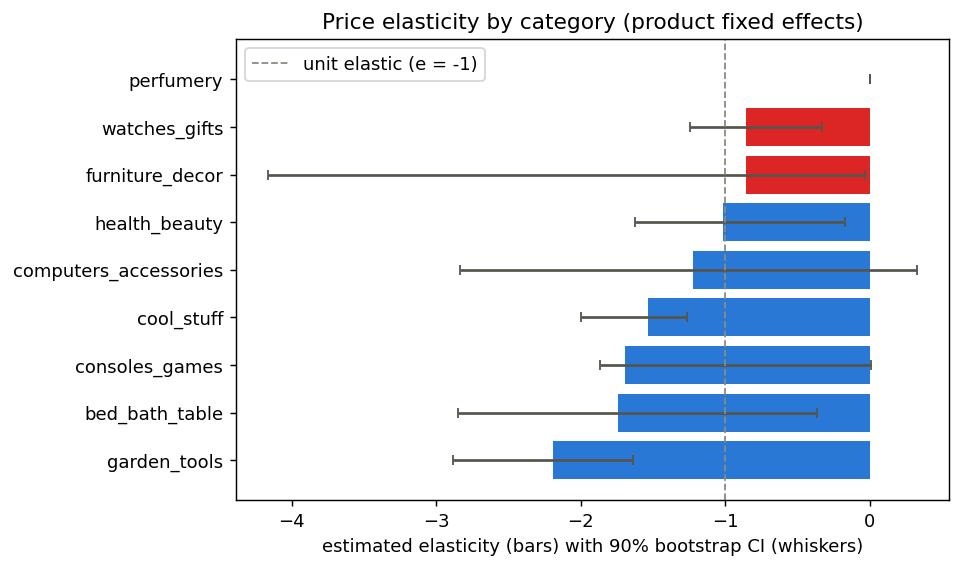

In [8]:
plot_df = cat_elasticities.sort_values("elasticity").reset_index(drop=True)
colors = ["#dc2626" if e > -1 else "#2a78d6" for e in plot_df["elasticity"]]
xerr_low = (plot_df["elasticity"] - plot_df["ci_low"]).clip(lower=0)
xerr_high = (plot_df["ci_high"] - plot_df["elasticity"]).clip(lower=0)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.barh(plot_df["product_category_name"], plot_df["elasticity"], color=colors,
        xerr=[xerr_low, xerr_high], capsize=3, ecolor="#56554c")
ax.axvline(-1, color="#8a8a80", ls="--", lw=1, label="unit elastic (e = -1)")
ax.set_xlabel("estimated elasticity (bars) with 90% bootstrap CI (whiskers)")
ax.set_title("Price elasticity by category (product fixed effects)")
ax.legend()
fig.tight_layout()
plt.show()


Categories to the left of the dashed line (e < -1) are **elastic**:
a price cut there tends to raise revenue. Categories to the right (red
bars) are **inelastic** -- demand barely moves with price, so cutting
price mostly just gives away margin. Note the R² values are generally
low: with only a handful of markdown events per product over ~20
months, there isn't a lot of within-product price variation to identify
from, so treat these as noisy, directional estimates rather than precise
numbers -- exactly the kind of small-sample caveat you'd flag in a real
pricing analysis. `perfumery` is the extreme case: only 2 products with
essentially no price variation in this sample, so its elasticity and CI
both collapse to 0 -- not "genuinely zero elasticity", just "not
identifiable from this data". A category with that little variation
would need either more history or a deliberate price-variation
experiment before its elasticity could be trusted at all.

## 3. Difference-in-differences: causal effect of markdowns

The dataset doesn't have an explicit "treatment/control" experiment, but
it does have `lag_price`, so we can build one: flag **markdown events**
(month-over-month price drops of 10%+), and for each event compare the
discounted product ("treated") against other products in the *same
category* that weren't marked down that month ("control"), over a
9-month window centered on the event (4 months before, 4 after). That
gives the standard 2x2 DiD setup:

`log(qty) ~ treated + post + treated x post`

The interaction term is the causal estimate: it nets out whatever else
was happening to the category that month (seasonality, a category-wide
promotion, a holiday) using the control group, the same way the naive
before/after comparison can't. The 90% confidence interval comes from a
cluster bootstrap over markdown events (see `bootstrap_did_ci`), since
resampling individual rows would understate the true uncertainty.


In [9]:
events = build_markdown_events(df, drop_threshold=0.10, window_months=4)
did = estimate_did(events)
did_ci = bootstrap_did_ci(events, n_boot=250)

print(f"Markdown events found: {did['n_events']}  (across {did['n_obs']} product-month observations)")
print(f"Naive before/after change for discounted products: {did['naive_pct']:+.1f}% demand")
print(f"DiD estimate (nets out the category-wide trend):    {did['did_pct']:+.1f}% demand  "
      f"(90% CI [{did_ci['ci_low_pct']:+.1f}%, {did_ci['ci_high_pct']:+.1f}%])")


Markdown events found: 65  (across 2232 product-month observations)
Naive before/after change for discounted products: +49.7% demand
DiD estimate (nets out the category-wide trend):    +50.9% demand  (90% CI [+36.7%, +67.7%])


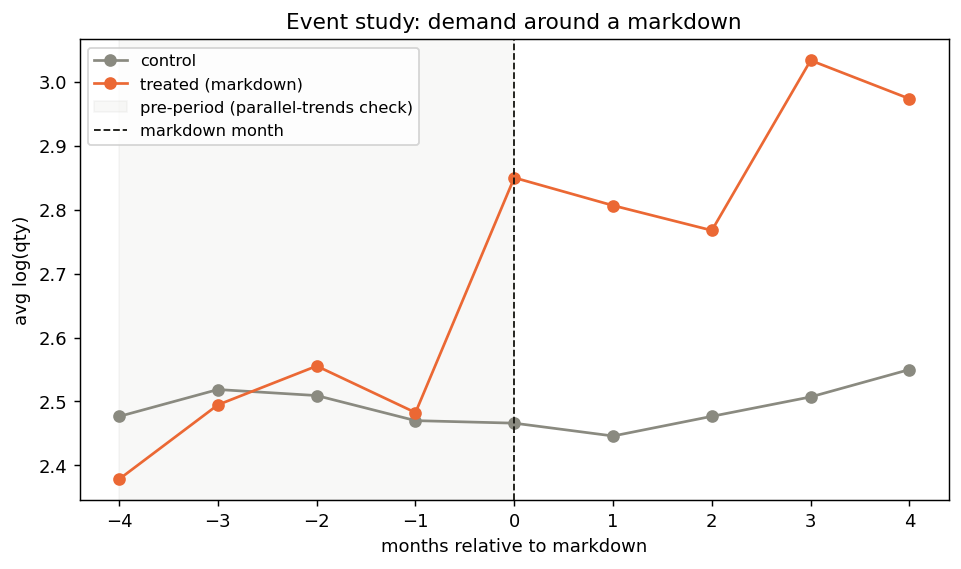

In [10]:
# event-study view: average log(qty), indexed to months relative to the
# markdown (-4..+4), treated vs control. The pre-period (-4..-1) is the
# parallel-trends check: if treated and control move together *before*
# the markdown, the post-period gap is credibly caused by the price cut
# rather than a pre-existing difference in trajectory.
e = events[events["rel_month"].between(-4, 4)]
agg = e.groupby(["rel_month", "treated"])["qty"].apply(lambda s: np.log(s).mean()).reset_index()
piv = agg.pivot(index="rel_month", columns="treated", values="qty")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(piv.index, piv[0], marker="o", color="#8a8a80", label="control")
ax.plot(piv.index, piv[1], marker="o", color="#eb6834", label="treated (markdown)")
ax.axvspan(-4, -0.001, color="#8a8a80", alpha=0.06, label="pre-period (parallel-trends check)")
ax.axvline(0, color="#14140f", ls="--", lw=1, label="markdown month")
ax.set_xlabel("months relative to markdown")
ax.set_ylabel("avg log(qty)")
ax.set_title("Event study: demand around a markdown")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


**Robustness check:** "markdown" was defined as a 10%+ month-over-month
price drop -- an arbitrary cutoff. If the DiD estimate swings wildly
depending on that choice, it's not a trustworthy number. Re-running the
whole pipeline at 8%, 10%, 12%, and 15% thresholds shows whether the
conclusion (a real, positive demand effect) survives that choice.


threshold  did_pct  naive_pct  n_events  n_obs
       8%     47.7       47.0        68   2358
      10%     50.9       49.7        65   2232
      12%     56.1       54.0        54   1871
      15%     65.8       63.0        41   1366


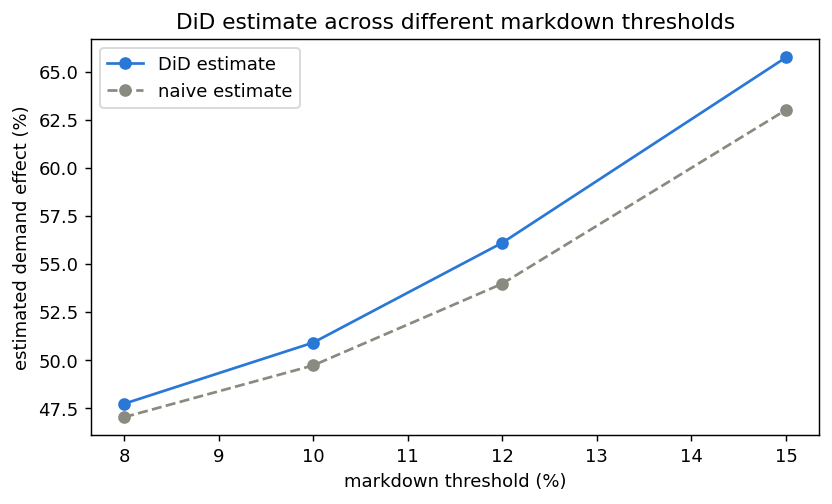

In [11]:
robustness = markdown_threshold_robustness(df, thresholds=(0.08, 0.10, 0.12, 0.15), window_months=4)
display_rob = robustness.copy()
display_rob["threshold"] = (display_rob["threshold"] * 100).round(0).astype(int).astype(str) + "%"
print(display_rob.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(robustness["threshold"] * 100, robustness["did_pct"], marker="o", color="#2a78d6", label="DiD estimate")
ax.plot(robustness["threshold"] * 100, robustness["naive_pct"], marker="o", color="#8a8a80", ls="--", label="naive estimate")
ax.set_xlabel("markdown threshold (%)")
ax.set_ylabel("estimated demand effect (%)")
ax.set_title("DiD estimate across different markdown thresholds")
ax.legend()
fig.tight_layout()
plt.show()


## 4. Price optimization

Pick a category, use its estimated (product-demeaned) elasticity, and
solve for the profit-maximizing price under the standard
constant-elasticity monopoly markup rule:

`P* = cost x e / (e + 1)`,  valid when `e < -1`

Since the dataset has no true unit-cost column, unit cost is assumed to
be a fixed fraction of the category's observed median price (55% here)
-- adjust `unit_cost_frac` to whatever margin assumption fits your
business.

In [12]:
CATEGORY = "garden_tools"   # try swapping this for any category with e < -1
opt = optimal_price_for_category(df, CATEGORY, unit_cost_frac=0.55)

print(f"Category: {CATEGORY}")
print(f"Estimated elasticity: {opt['elasticity']:.2f}  (R^2={opt['r2']:.2f})")
print(f"Assumed unit cost:    ${opt['unit_cost']:.2f}")
print(f"Current median price: ${opt['median_price']:.2f}")
if opt["optimal_price"] is not None:
    print(f"Profit-optimal price: ${opt['optimal_price']:.2f}")
else:
    print("Elasticity isn't below -1, so the constant-elasticity markup rule has no finite optimum here --")
    print("demand is too inelastic in this sample for a monopoly markup to make sense; try a different category.")


Category: garden_tools
Estimated elasticity: -2.19  (R^2=0.20)
Assumed unit cost:    $43.44
Current median price: $78.98
Profit-optimal price: $79.85


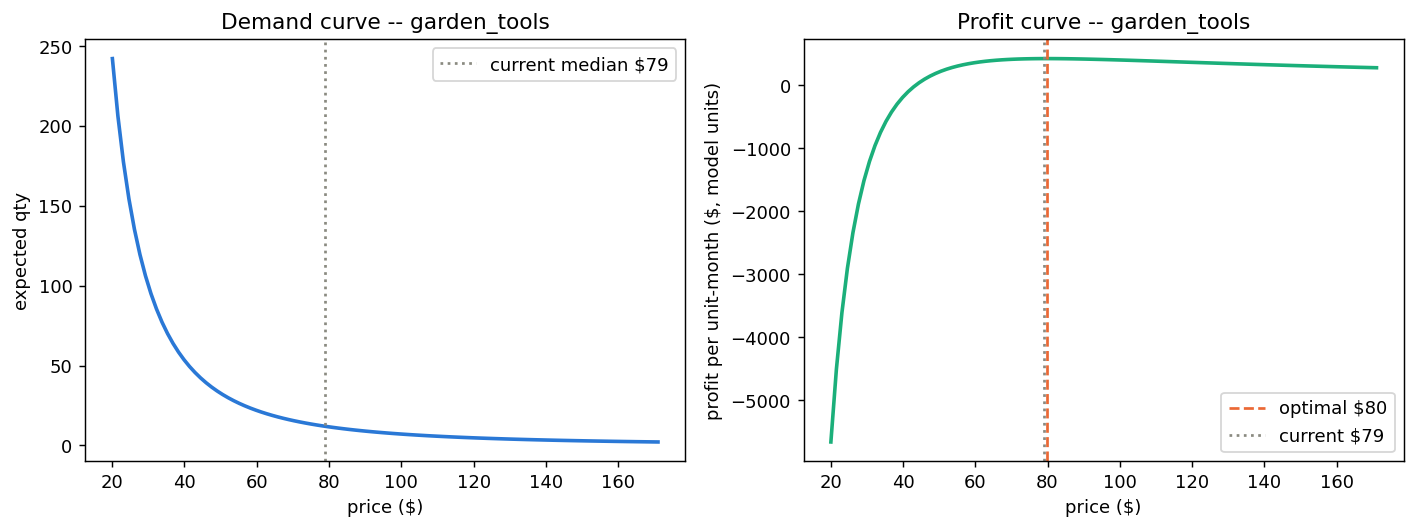

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(opt["price_grid"], opt["demand_grid"], color="#2a78d6", lw=2)
axes[0].axvline(opt["median_price"], color="#8a8a80", ls=":", label=f"current median ${opt['median_price']:.0f}")
axes[0].set_xlabel("price ($)"); axes[0].set_ylabel("expected qty")
axes[0].set_title(f"Demand curve -- {CATEGORY}")
axes[0].legend()

axes[1].plot(opt["price_grid"], opt["profit_grid"], color="#1baf7a", lw=2)
if opt["optimal_price"] is not None:
    axes[1].axvline(opt["optimal_price"], color="#eb6834", ls="--",
                     label=f"optimal ${opt['optimal_price']:.0f}")
axes[1].axvline(opt["median_price"], color="#8a8a80", ls=":", label=f"current ${opt['median_price']:.0f}")
axes[1].set_xlabel("price ($)"); axes[1].set_ylabel("profit per unit-month ($, model units)")
axes[1].set_title(f"Profit curve -- {CATEGORY}")
axes[1].legend()

fig.tight_layout()
plt.show()


## 5. Dynamic pricing

Static optimal pricing has a weakness: it commits to one price for the
whole season regardless of how demand actually unfolds. If real demand
comes in soft, a high "optimal" price can leave a lot of inventory
unsold at the end of the season -- and unsold stock typically gets
salvaged at a fraction of cost, which eats right back into the margin
the optimal price was supposed to capture.

This section simulates a **16-week selling season** for one category
under three pricing policies, all facing the *same* simulated demand and
the *same* competitor price path, so the comparison is apples-to-apples:

- **current** -- hold at today's observed median price the whole season
- **optimal** -- hold at the static constant-elasticity price the whole season
- **dynamic** -- anchor to the optimal price, then adjust weekly based on
  two live signals: **sell-through pace** (behind the plan -> mark down;
  see `dynamic_price_rule` in `analysis.py`) and **competitor price**
  (pull toward the market). Price moves are capped at +/-25% of the
  anchor per week so the rule can't propose unrealistic swings.

Any inventory left at the end of the season is salvaged at 30% of unit
cost (a standard clearance write-down), so ending stock is scored as a
real cost -- not ignored.

In [14]:
CATEGORY2 = "cool_stuff"
traj, policy_summary = compare_pricing_policies(df, CATEGORY2, weeks=16,
                                                 start_inventory=220, seed=11)
print(policy_summary[["policy","avg_price","units_sold","leftover_units",
                       "salvage_loss","total_revenue","total_profit"]]
      .round(2).to_string(index=False))


 policy  avg_price  units_sold  leftover_units  salvage_loss  total_revenue  total_profit
current      84.03         220               0          0.00       18486.60       8318.97
optimal     132.44         136              84       2717.53       18012.16       9009.19
dynamic     115.34         168              52       1682.28       19335.23       9888.58


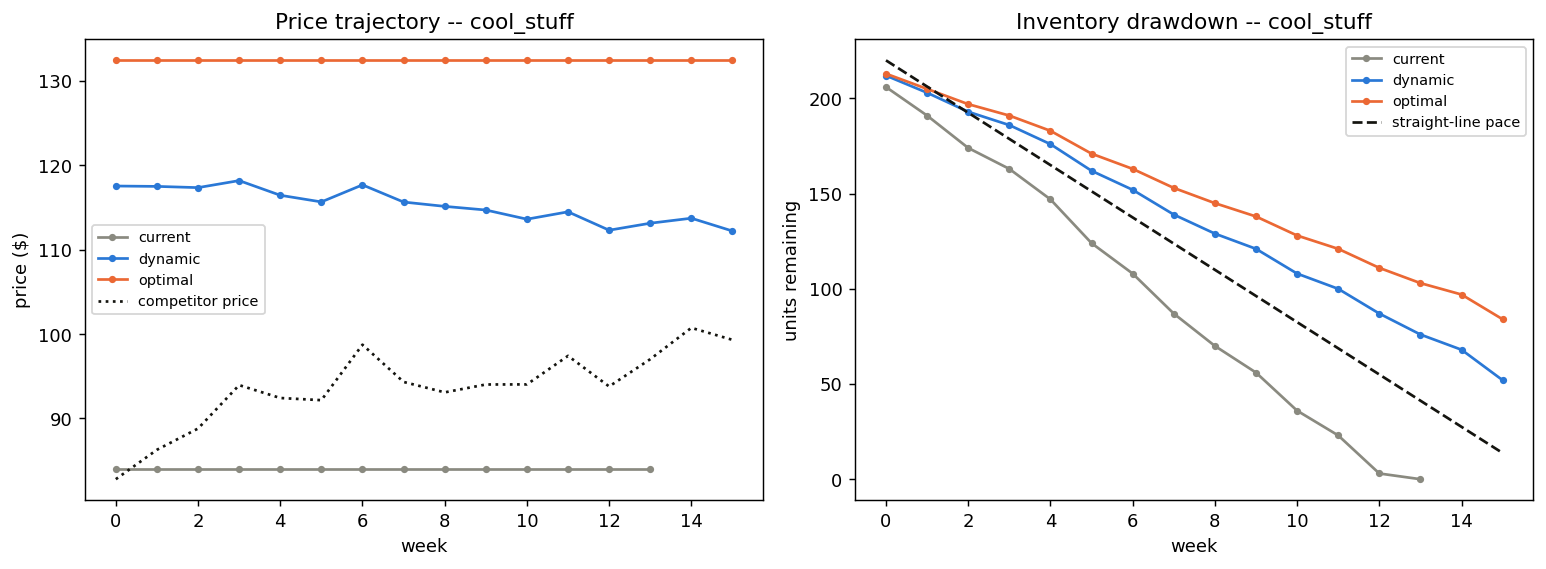

In [15]:
colors = {"current": "#8a8a80", "optimal": "#eb6834", "dynamic": "#2a78d6"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for policy, g in traj.groupby("policy"):
    axes[0].plot(g["week"], g["price"], marker="o", ms=3, color=colors[policy], label=policy)
comp = traj[traj.policy == "dynamic"]
axes[0].plot(comp["week"], comp["comp_price"], color="#14140f", ls=":", label="competitor price")
axes[0].set_xlabel("week"); axes[0].set_ylabel("price ($)")
axes[0].set_title(f"Price trajectory -- {CATEGORY2}")
axes[0].legend(fontsize=8)

for policy, g in traj.groupby("policy"):
    axes[1].plot(g["week"], g["remaining"], marker="o", ms=3, color=colors[policy], label=policy)
axes[1].plot(comp["week"], comp["target_remaining"], color="#14140f", ls="--", label="straight-line pace")
axes[1].set_xlabel("week"); axes[1].set_ylabel("units remaining")
axes[1].set_title(f"Inventory drawdown -- {CATEGORY2}")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


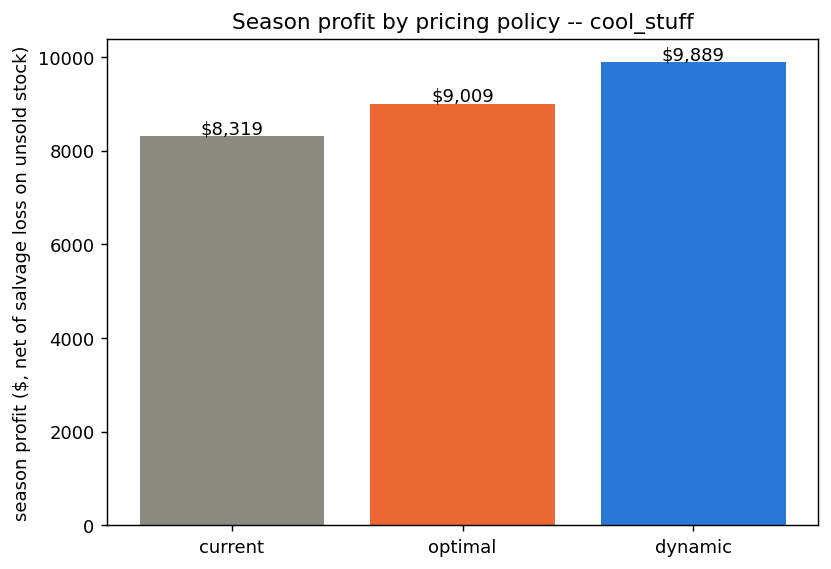

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(len(policy_summary))
ax.bar(x, policy_summary["total_profit"], color=[colors[p] for p in policy_summary["policy"]])
for i, v in enumerate(policy_summary["total_profit"]):
    ax.text(i, v + 50, f"${v:,.0f}", ha="center", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(policy_summary["policy"])
ax.set_ylabel("season profit ($, net of salvage loss on unsold stock)")
ax.set_title(f"Season profit by pricing policy -- {CATEGORY2}")
fig.tight_layout()
plt.show()


The static **current** price sells through cleanly but leaves
margin on the table. The static **optimal** price captures a higher
per-unit margin but, being rigid, ends the season with meaningfully more
unsold inventory -- the salvage write-down claws back a chunk of that
theoretical advantage. **Dynamic** pricing starts at the same
theoretically-justified anchor but adapts down when sell-through lags
the plan, landing on the highest total season profit of the three by
capturing most of the optimal price's margin while avoiding most of its
leftover-inventory risk.

This is a simple rule-based policy, not a trained model -- the next step
up would be a proper reinforcement-learning or dynamic-programming
formulation of the same markdown-optimization problem, using the
elasticity estimate as the demand model it optimizes against.

## 6. Summary & caveats

- **Elasticity** varies a lot by category and is estimated with real
  noise here -- small per-product sample sizes mean wide confidence
  intervals (see the whiskers in the chart above); treat the ranking as
  directional, and always check the interval before acting on a single
  point estimate.
- **DiD** is the right tool whenever you want the *causal* effect of a
  price change rather than a before/after number contaminated by
  whatever else was moving demand that month -- the gap between the
  naive and DiD estimates above **is** that contamination. The
  parallel-trends chart and the threshold-robustness check both support
  treating the direction and rough size of the effect as real, even
  though the exact percentage moves somewhat with the markdown
  definition.
- **Price optimization** here uses a simple constant-elasticity /
  constant-margin assumption. Real pricing decisions should sanity-check
  against competitor reactions (`comp_1/2/3` are sitting right there in
  this dataset), brand/traffic effects of price image, and inventory
  constraints -- none of which the static model sees.
- **Dynamic pricing** shows why the static optimum isn't the end of the
  story: reacting to real sell-through and competitor moves recovers
  profit that a single fixed price leaves on the table in either
  direction (selling too cheap, or getting stuck with unsold stock).
- Swap in the real `retail_price.csv` (same column names, day-first
  dates) to get the real numbers; everything else in this notebook runs
  unchanged.
- **What would still make this stronger:** validating the elasticity
  model out-of-sample (fit on 2017, check it predicts 2018), and
  optimizing the dynamic-pricing rule's two weights rather than
  hand-picking them -- both flagged here rather than done, in the
  interest of keeping the notebook runnable in well under a minute.



# 7. REAL-DATA EXPERIMENTS — Phase 1

This section uses the actual `retail_price.csv` supplied with the project. It does not generate synthetic data.

The goal is to produce experimental evidence for the teacher's requirements: **real-data pricing results** and measurable model performance.

Important: the dataset contains pricing/demand/competitor information, but it does **not** contain actual inventory-on-hand or lead-time records. Inventory experiments later in this notebook are therefore explicitly labeled as **scenario simulations**, not historical inventory measurements.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Force the experiment section to use the real CSV.
if not os.path.exists('retail_price.csv'):
    raise FileNotFoundError('Place retail_price.csv in the same folder as this notebook.')

real_df = pd.read_csv('retail_price.csv', parse_dates=['month_year'], dayfirst=True)
print('REAL DATASET CHECK')
print('Shape:', real_df.shape)
print('Date range:', real_df['month_year'].min().date(), 'to', real_df['month_year'].max().date())
print('Products:', real_df['product_id'].nunique())
print('Categories:', real_df['product_category_name'].nunique())
print('Missing values:', int(real_df.isna().sum().sum()))
display(real_df[['product_id','product_category_name','month_year','qty','unit_price','comp_1','comp_2','comp_3','lag_price']].head())


## 7.1 Experiment A — Real-data elasticity and bounded price optimization

For every category we estimate the product-fixed-effects log-log elasticity, then re-anchor the demand curve at the category's observed median price and quantity. We evaluate profit on a **bounded price grid (60%–140% of the observed median)** instead of relying only on the closed-form markup formula. This prevents extreme values when estimated elasticity is close to −1.

The resulting price is a **model-implied scenario optimum within the tested range**, not a guaranteed business recommendation. Unit cost remains an assumption because the CSV does not contain true COGS.


In [ ]:
def real_data_price_grid_experiment(df, unit_cost_frac=0.55, lo=0.60, hi=1.40, n_grid=161):
    rows, curves = [], {}
    for cat, g in df.groupby('product_category_name'):
        g = g.copy()
        g['log_p'] = np.log(g['unit_price'])
        g['log_q'] = np.log(g['qty'])
        g['log_p_dm'] = g['log_p'] - g.groupby('product_id')['log_p'].transform('mean')
        g['log_q_dm'] = g['log_q'] - g.groupby('product_id')['log_q'].transform('mean')
        beta = np.linalg.lstsq(np.c_[np.ones(len(g)), g['log_p_dm']], g['log_q_dm'], rcond=None)[0]
        e = float(beta[1])
        median_p = float(g['unit_price'].median())
        median_q = float(g['qty'].median())
        unit_cost = unit_cost_frac * median_p
        grid = np.linspace(lo * median_p, hi * median_p, n_grid)
        demand = median_q * (grid / median_p) ** e
        revenue = grid * demand
        profit = (grid - unit_cost) * demand
        j = int(np.argmax(profit))
        rows.append({
            'category': cat, 'elasticity': e, 'median_price': median_p,
            'unit_cost_assumed': unit_cost, 'grid_optimal_price': grid[j],
            'price_change_pct': (grid[j] / median_p - 1) * 100,
            'predicted_qty_at_median': median_q,
            'predicted_qty_at_optimal': demand[j],
            'profit_at_median': (median_p - unit_cost) * median_q,
            'profit_at_optimal': profit[j],
            'profit_change_pct': (profit[j] / ((median_p-unit_cost)*median_q) - 1) * 100 if (median_p-unit_cost)*median_q > 0 else np.nan
        })
        curves[cat] = pd.DataFrame({'price': grid, 'demand': demand, 'revenue': revenue, 'profit': profit})
    return pd.DataFrame(rows).sort_values('category').reset_index(drop=True), curves

real_price_results, real_price_curves = real_data_price_grid_experiment(real_df)
display(real_price_results.round(2))


In [ ]:
# Demand and profit curves for the category used earlier in the notebook.
REAL_EXPERIMENT_CATEGORY = 'garden_tools'
curve = real_price_curves[REAL_EXPERIMENT_CATEGORY]
row = real_price_results[real_price_results.category == REAL_EXPERIMENT_CATEGORY].iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(curve['price'], curve['demand'], lw=2)
ax.axvline(row['median_price'], ls=':', label=f"observed median ${row['median_price']:.2f}")
ax.axvline(row['grid_optimal_price'], ls='--', label=f"grid optimum ${row['grid_optimal_price']:.2f}")
ax.set_xlabel('Price ($)'); ax.set_ylabel('Predicted quantity')
ax.set_title(f'Real-data demand curve — {REAL_EXPERIMENT_CATEGORY}')
ax.legend(); fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(curve['price'], curve['profit'], lw=2)
ax.axvline(row['median_price'], ls=':', label='observed median')
ax.axvline(row['grid_optimal_price'], ls='--', label='grid optimum')
ax.set_xlabel('Price ($)'); ax.set_ylabel('Expected profit (model units)')
ax.set_title(f'Real-data profit curve — {REAL_EXPERIMENT_CATEGORY}')
ax.legend(); fig.tight_layout(); plt.show()


## 7.2 Experiment B — Out-of-time real-data demand validation

To avoid evaluating the demand model only on the observations used to estimate it, this experiment holds out the **latest 30% of observations for each product**. Category elasticity is estimated using training data only; each product's demand level is anchored using its training observations. We compare this model with a simple product-level mean baseline.

Metrics: MAE, RMSE and MAPE on the held-out observations. This is a forecasting validation, not a causal test.


In [ ]:
def fit_category_elasticity(train_g):
    x = np.log(train_g['unit_price'].astype(float))
    y = np.log(train_g['qty'].astype(float))
    xd = x - x.groupby(train_g['product_id']).transform('mean')
    yd = y - y.groupby(train_g['product_id']).transform('mean')
    if np.isclose(np.var(xd), 0):
        return 0.0
    return float(np.linalg.lstsq(np.c_[np.ones(len(train_g)), xd], yd, rcond=None)[0][1])

train_parts, test_parts = [], []
for pid, g in real_df.sort_values('month_year').groupby('product_id'):
    cut = int(np.floor(len(g) * 0.70))
    train_parts.append(g.iloc[:cut])
    test_parts.append(g.iloc[cut:])
train = pd.concat(train_parts, ignore_index=True)
test = pd.concat(test_parts, ignore_index=True)

elasticity_train = {cat: fit_category_elasticity(g) for cat, g in train.groupby('product_category_name')}
intercepts = {}
for pid, g in train.groupby('product_id'):
    e = elasticity_train[g['product_category_name'].iloc[0]]
    intercepts[pid] = float(np.mean(np.log(g['qty']) - e*np.log(g['unit_price'])))

test = test.copy()
test['elasticity'] = test['product_category_name'].map(elasticity_train)
test['intercept'] = test['product_id'].map(intercepts)
test['pred_qty'] = np.exp(test['intercept'] + test['elasticity']*np.log(test['unit_price']))
test['baseline_qty'] = test['product_id'].map(train.groupby('product_id')['qty'].mean())

actual = test['qty'].to_numpy(float)
pred = test['pred_qty'].to_numpy(float)
base = test['baseline_qty'].to_numpy(float)
metrics = pd.DataFrame([
    {'model':'Elasticity demand model','MAE':np.mean(np.abs(actual-pred)),
     'RMSE':np.sqrt(np.mean((actual-pred)**2)),
     'MAPE_%':np.mean(np.abs((actual-pred)/actual))*100},
    {'model':'Product mean baseline','MAE':np.mean(np.abs(actual-base)),
     'RMSE':np.sqrt(np.mean((actual-base)**2)),
     'MAPE_%':np.mean(np.abs((actual-base)/actual))*100}
])
print(f'Train rows: {len(train)} | Test rows: {len(test)}')
display(metrics.round(3))


# 8. PRICING FACTOR EXPERIMENTS

These experiments answer the teacher's requirement to test **the factors affecting pricing**. The factors available in the real CSV are used directly where possible. Inventory and lead-time factors are scenario variables because they are not present in `retail_price.csv`.


## 8.1 Factor 1 — Price elasticity sensitivity

Question: **If the estimated elasticity is different, how does the model-implied price change?**

This is a sensitivity experiment around the real-data elasticity rather than a new causal estimate.


In [ ]:
def bounded_optimal_price(median_price, median_qty, elasticity, cost_frac=0.55, lo=0.60, hi=1.40, n=161):
    cost = cost_frac * median_price
    grid = np.linspace(lo*median_price, hi*median_price, n)
    demand = median_qty * (grid/median_price)**elasticity
    profit = (grid-cost)*demand
    j = np.argmax(profit)
    return grid[j], demand[j], profit[j]

cat = 'garden_tools'
base_row = real_price_results[real_price_results.category == cat].iloc[0]
e0 = base_row['elasticity']
sensitivity = []
for delta in [-0.60,-0.40,-0.20,0,0.20,0.40,0.60]:
    e = e0 + delta
    p,d,q = bounded_optimal_price(base_row['median_price'], base_row['predicted_qty_at_median'], e)
    sensitivity.append({'elasticity':e,'optimal_price':p,'predicted_demand':d,'expected_profit':q})
elasticity_sensitivity = pd.DataFrame(sensitivity)
display(elasticity_sensitivity.round(2))

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(elasticity_sensitivity['elasticity'], elasticity_sensitivity['optimal_price'], marker='o')
ax.axvline(e0, ls=':', label=f'estimated e={e0:.2f}')
ax.set_xlabel('Elasticity'); ax.set_ylabel('Model-implied optimal price ($)')
ax.set_title('Sensitivity of price to elasticity — garden_tools')
ax.legend(); fig.tight_layout(); plt.show()


## 8.2 Factor 2 — Competitor-price sensitivity (real data)

The CSV contains three competitor-price fields. We use their category average as a market reference and vary that reference by ±20%. The existing rule-based dynamic pricing logic then shows how the recommendation responds.

This is a **scenario experiment**; it does not claim that competitor price has a causal effect equal to the simulated change.


In [ ]:
g = real_df[real_df['product_category_name'] == cat].copy()
base_price = float(g['unit_price'].median())
unit_cost = 0.55 * base_price
comp_base = float(g[['comp_1','comp_2','comp_3']].mean().mean())
start_inventory = 220
current_remaining = 150
target_remaining = start_inventory * (1 - 8/16)

comp_rows=[]
for m in [-0.20,-0.10,0,0.10,0.20]:
    cp = comp_base*(1+m)
    rp = dynamic_price_rule(current_remaining, target_remaining, start_inventory,
                            base_price, cp, unit_cost)
    comp_rows.append({'competitor_change_%':m*100,'competitor_reference':cp,'recommended_price':rp,
                      'price_change_vs_current_%':(rp/base_price-1)*100})
competitor_experiment = pd.DataFrame(comp_rows)
display(competitor_experiment.round(2))

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(competitor_experiment['competitor_change_%'], competitor_experiment['recommended_price'], marker='o')
ax.axhline(base_price, ls=':', label='observed median price')
ax.set_xlabel('Competitor price change (%)'); ax.set_ylabel('Recommended price ($)')
ax.set_title('Competitor-price sensitivity — rule-based pricing')
ax.legend(); fig.tight_layout(); plt.show()


## 8.3 Factor 3 — Inventory level sensitivity

Inventory is not observed in the Retail Price Optimization CSV, so this is a controlled scenario experiment. We hold the current remaining stock at 100 units and vary starting inventory. The rule compares remaining stock with the expected straight-line sell-through target and adjusts price accordingly.


In [ ]:
inventory_rows=[]
for start_inv in [120,160,220,300,400]:
    remaining=100
    target=start_inv*(1-8/16)
    rp=dynamic_price_rule(remaining,target,start_inv,base_price,comp_base,unit_cost)
    inventory_rows.append({'start_inventory':start_inv,'current_remaining':remaining,
                           'target_remaining_week8':target,'recommended_price':rp,
                           'price_change_vs_current_%':(rp/base_price-1)*100})
inventory_experiment=pd.DataFrame(inventory_rows)
display(inventory_experiment.round(2))

fig, ax=plt.subplots(figsize=(7,4.5))
ax.plot(inventory_experiment['start_inventory'],inventory_experiment['recommended_price'],marker='o')
ax.axhline(base_price,ls=':',label='observed median price')
ax.set_xlabel('Starting inventory (units)'); ax.set_ylabel('Recommended price ($)')
ax.set_title('Inventory-level sensitivity — rule-based pricing')
ax.legend(); fig.tight_layout(); plt.show()


## 8.4 Factor 4 — Lead time and safety-stock experiment

Lead time and safety stock primarily affect **inventory risk**, but they can influence pricing once inventory pressure is fed into the combined decision rule. Weekly demand is approximated from the real category demand. A 95% one-sided service factor (z = 1.645) is used only for this scenario calculation.


In [ ]:
weekly_mean = float(g['qty'].mean()/4.345)
weekly_std = float(g['qty'].std(ddof=1)/4.345)
z = 1.645
lead_rows=[]
for lead in [1,2,3,4,6]:
    for safety_weeks in [0,1,2]:
        safety_stock = safety_weeks*weekly_mean
        rop = weekly_mean*lead + z*weekly_std*np.sqrt(lead) + safety_stock
        lead_rows.append({'lead_time_weeks':lead,'safety_stock_weeks':safety_weeks,
                          'safety_stock_units':safety_stock,'reorder_point_units':rop})
lead_experiment=pd.DataFrame(lead_rows)
display(lead_experiment.round(2))

fig, ax=plt.subplots(figsize=(8,4.5))
for sw, gg in lead_experiment.groupby('safety_stock_weeks'):
    ax.plot(gg['lead_time_weeks'],gg['reorder_point_units'],marker='o',label=f'safety stock {sw} week(s)')
ax.set_xlabel('Lead time (weeks)'); ax.set_ylabel('Reorder point (units)')
ax.set_title(f'Reorder-point sensitivity — {cat}')
ax.legend(); fig.tight_layout(); plt.show()


## 8.5 Combined experiment — Phase 1 + Phase 2

This is the key experiment for the proposed system. We combine:

**real-data elasticity + competitor price + demand anchor + inventory + lead time + safety stock**

The combined engine is intentionally transparent. It starts from the bounded price optimum, then adjusts it according to competitor pressure and inventory pressure. The inventory action is derived from reorder-point logic.

This is a **decision-rule prototype**, not a trained reinforcement-learning model.


In [ ]:
def combined_decision(category, current_inventory, lead_time_weeks, safety_stock_weeks,
                      competitor_multiplier=1.0, cost_frac=0.55):
    gg=real_df[real_df['product_category_name']==category]
    rr=real_price_results[real_price_results.category==category].iloc[0]
    median_price=float(rr['median_price'])
    elasticity=float(rr['elasticity'])
    median_qty=float(rr['predicted_qty_at_median'])
    unit_cost=cost_frac*median_price
    base_opt, _, _ = bounded_optimal_price(median_price, median_qty, elasticity, cost_frac)
    comp=float(gg[['comp_1','comp_2','comp_3']].mean().mean())*competitor_multiplier

    weekly_mean=float(gg['qty'].mean()/4.345)
    weekly_std=float(gg['qty'].std(ddof=1)/4.345)
    safety_stock=safety_stock_weeks*weekly_mean
    rop=weekly_mean*lead_time_weeks + 1.645*weekly_std*np.sqrt(lead_time_weeks) + safety_stock
    if current_inventory < rop:
        inventory_action='REORDER / PROTECT STOCK'
    elif current_inventory > 1.30*rop:
        inventory_action='HIGH STOCK / INCREASE SELL-THROUGH'
    else:
        inventory_action='MAINTAIN'

    # Transparent price adjustment around the model-implied optimum.
    price=base_opt
    price += 0.30*(comp-price)
    inventory_pressure=(rop-current_inventory)/max(rop,1)
    price += np.clip(0.10*inventory_pressure*price, -0.08*price, 0.08*price)
    price=max(price,unit_cost*1.05)
    demand=median_qty*(price/median_price)**elasticity
    expected_profit=(price-unit_cost)*demand
    return {'category':category,'elasticity':elasticity,'median_price':median_price,
            'model_base_optimal_price':base_opt,'competitor_price':comp,
            'lead_time_weeks':lead_time_weeks,'safety_stock_weeks':safety_stock_weeks,
            'reorder_point':rop,'current_inventory':current_inventory,
            'inventory_action':inventory_action,'recommended_price':price,
            'expected_demand':demand,'expected_profit':expected_profit}

combined_scenarios=[
    ('Baseline',220,2,1,1.00),
    ('Low inventory',20,2,1,1.00),
    ('High inventory',400,2,1,1.00),
    ('Competitor lower',220,2,1,0.90),
    ('Competitor higher',220,2,1,1.10),
    ('Long lead time',80,6,2,1.00),
    ('Combined stress',20,6,2,1.10),
]
combined=[]
for name,inv,lt,sw,cm in combined_scenarios:
    r=combined_decision(cat,inv,lt,sw,cm)
    r['scenario']=name
    combined.append(r)
combined_df=pd.DataFrame(combined)
cols=['scenario','current_inventory','lead_time_weeks','safety_stock_weeks','competitor_price',
      'reorder_point','inventory_action','recommended_price','expected_demand','expected_profit']
display(combined_df[cols].round(2))


## 8.6 Experimental interpretation template

When presenting these experiments, use the following structure:

1. **Input factor changed** — state exactly what was changed.
2. **Model response** — report recommended price, expected demand, profit or reorder point.
3. **Direction of change** — explain whether the output increased/decreased and why according to the model.
4. **Limitation** — distinguish real-data estimates from scenario assumptions.

For example: *“When the simulated competitor reference increases, the rule-based pricing component moves the recommended price toward the competitor price. This demonstrates sensitivity to competition, but it is not evidence of a causal competitor-price effect.”*


# 9. Applied ML demand model for dynamic pricing + inventory

The log-log OLS model above is kept as an interpretable benchmark, but the
decision model below is more practical for a pricing/inventory workflow:

- It forecasts baseline demand from competitor prices, product/category,
  seasonality, freight, product attributes, lag price and a traffic proxy.
- It is validated out-of-time by product, so the test set is later than the
  train set for each SKU.
- Pricing is selected by simulating candidate prices. The ML model supplies
  baseline demand, while a clipped elasticity guardrail keeps price response
  monotonic and business-safe.
- Inventory remains part of the decision through reorder point, safety stock,
  current stock, and sell-through pressure.

This makes the notebook closer to an operational decision-support prototype:
OLS explains price sensitivity; the ML model drives demand forecasting; the
hybrid optimizer recommends actions.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import TransformedTargetRegressor


def add_operational_features(frame):
    f = frame.copy()
    f["month_year"] = pd.to_datetime(f["month_year"], dayfirst=True, errors="coerce")
    f["month"] = f["month_year"].dt.month.fillna(f.get("month", 1)).astype(int)
    f["year"] = f["month_year"].dt.year.fillna(f.get("year", 2017)).astype(int)
    competitor_cols = ["comp_1", "comp_2", "comp_3"]
    f["comp_avg"] = f[competitor_cols].mean(axis=1)
    f["comp_min"] = f[competitor_cols].min(axis=1)
    f["comp_max"] = f[competitor_cols].max(axis=1)
    f["price_gap_comp_avg"] = f["unit_price"] - f["comp_avg"]
    f["price_ratio_comp_avg"] = f["unit_price"] / f["comp_avg"].replace(0, np.nan)
    f["price_gap_lag"] = f["unit_price"] - f["lag_price"]
    f["price_ratio_lag"] = f["unit_price"] / f["lag_price"].replace(0, np.nan)
    f["freight_ratio_price"] = f["freight_price"] / f["unit_price"].replace(0, np.nan)
    f = f.replace([np.inf, -np.inf], np.nan)
    return f


applied_df = add_operational_features(real_df)

CATEGORICAL_FEATURES = ["product_id", "product_category_name"]
NUMERIC_FEATURES = [
    "unit_price", "freight_price", "lag_price",
    "comp_1", "comp_2", "comp_3", "comp_avg", "comp_min", "comp_max",
    "price_gap_comp_avg", "price_ratio_comp_avg", "price_gap_lag",
    "price_ratio_lag", "freight_ratio_price",
    "product_name_lenght", "product_description_lenght", "product_photos_qty",
    "product_weight_g", "product_score", "customers",
    "weekday", "weekend", "holiday", "month", "year", "s", "volume",
]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES

model_df = applied_df.dropna(subset=FEATURE_COLUMNS + ["qty"]).copy()
train_parts, test_parts = [], []
for _, g in model_df.sort_values("month_year").groupby("product_id"):
    cut = int(np.floor(len(g) * 0.70))
    cut = min(max(cut, 1), len(g) - 1)
    train_parts.append(g.iloc[:cut])
    test_parts.append(g.iloc[cut:])

train_ml = pd.concat(train_parts, ignore_index=True)
test_ml = pd.concat(test_parts, ignore_index=True)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
        ("num", "passthrough", NUMERIC_FEATURES),
    ],
    remainder="drop",
)

base_regressor = HistGradientBoostingRegressor(
    max_iter=350,
    learning_rate=0.045,
    max_leaf_nodes=15,
    l2_regularization=0.08,
    random_state=42,
)

demand_model = TransformedTargetRegressor(
    regressor=Pipeline([("prep", preprocess), ("model", base_regressor)]),
    func=np.log1p,
    inverse_func=np.expm1,
)

demand_model.fit(train_ml[FEATURE_COLUMNS], train_ml["qty"])
ml_pred = np.clip(demand_model.predict(test_ml[FEATURE_COLUMNS]), 0, None)

product_baseline = train_ml.groupby("product_id")["qty"].mean()
global_baseline = float(train_ml["qty"].mean())
baseline_pred = test_ml["product_id"].map(product_baseline).fillna(global_baseline).to_numpy()

ml_metrics = pd.DataFrame([
    {
        "model": "Applied ML demand model",
        "MAE": mean_absolute_error(test_ml["qty"], ml_pred),
        "RMSE": mean_squared_error(test_ml["qty"], ml_pred) ** 0.5,
        "R2": r2_score(test_ml["qty"], ml_pred),
    },
    {
        "model": "Product mean baseline",
        "MAE": mean_absolute_error(test_ml["qty"], baseline_pred),
        "RMSE": mean_squared_error(test_ml["qty"], baseline_pred) ** 0.5,
        "R2": r2_score(test_ml["qty"], baseline_pred),
    },
])

print(f"Applied ML train rows: {len(train_ml)} | test rows: {len(test_ml)}")
display(ml_metrics.round(3))

comparison = test_ml[["product_id", "product_category_name", "month_year", "qty", "unit_price"]].copy()
comparison["pred_qty_ml"] = ml_pred
comparison["baseline_qty"] = baseline_pred
display(comparison.head(12).round(2))


In [ ]:
# Permutation importance gives a business-readable explanation without
# reverting to a purely linear log-log demand model.
importance = permutation_importance(
    demand_model,
    test_ml[FEATURE_COLUMNS],
    test_ml["qty"],
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
)

importance_df = (
    pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance_mae_reduction": importance.importances_mean,
        "std": importance.importances_std,
    })
    .sort_values("importance_mae_reduction", ascending=False)
    .head(12)
)
display(importance_df.round(4))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(test_ml["qty"], ml_pred, alpha=0.65)
upper = max(float(test_ml["qty"].max()), float(np.max(ml_pred)))
ax.plot([0, upper], [0, upper], ls="--", color="black", lw=1)
ax.set_xlabel("Actual quantity")
ax.set_ylabel("Predicted quantity")
ax.set_title("Applied ML demand model - out-of-time validation")
fig.tight_layout()
plt.show()


In [ ]:
def make_price_scenarios(context_row, candidate_prices, competitor_multiplier=1.0):
    scenarios = pd.DataFrame([context_row.to_dict()] * len(candidate_prices))
    scenarios["unit_price"] = candidate_prices
    for col in ["comp_1", "comp_2", "comp_3"]:
        scenarios[col] = scenarios[col] * competitor_multiplier
    return add_operational_features(scenarios)


def elasticity_guardrail(category):
    row = real_price_results[real_price_results["category"] == category]
    if row.empty:
        return -1.0
    e = float(row.iloc[0]["elasticity"])
    if (not np.isfinite(e)) or e >= -0.15:
        e = -0.8
    return float(np.clip(e, -3.0, -0.30))


def forecast_price_grid(
    category,
    current_inventory,
    lead_time_weeks=2,
    safety_stock_weeks=1,
    competitor_multiplier=1.0,
    cost_frac=0.55,
    lo=0.70,
    hi=1.30,
    n_grid=121,
):
    g = model_df[model_df["product_category_name"] == category].sort_values("month_year")
    if g.empty:
        raise ValueError(f"Unknown category: {category}")

    context = g.iloc[-1].copy()
    observed_price = float(g["unit_price"].median())
    unit_cost = cost_frac * observed_price
    min_price = max(unit_cost * 1.05, lo * observed_price)
    max_price = hi * observed_price
    candidate_prices = np.linspace(min_price, max_price, n_grid)

    # Operational hybrid:
    # - ML estimates baseline demand for the current business context.
    # - A clipped elasticity response gives monotonic, business-safe price effects.
    baseline_scenario = make_price_scenarios(context, [observed_price], competitor_multiplier)
    baseline_demand = float(np.clip(demand_model.predict(baseline_scenario[FEATURE_COLUMNS])[0], 0, None))
    e = elasticity_guardrail(category)
    predicted_qty = baseline_demand * (candidate_prices / observed_price) ** e

    weekly_qty = g["qty"].astype(float) / 4.345
    weekly_mean = float(weekly_qty.mean())
    weekly_std = float(weekly_qty.std(ddof=1))
    safety_stock = safety_stock_weeks * weekly_mean
    reorder_point = weekly_mean * lead_time_weeks + 1.645 * weekly_std * np.sqrt(lead_time_weeks) + safety_stock

    if current_inventory < reorder_point:
        inventory_action = "REORDER / PROTECT STOCK"
    elif current_inventory > 1.30 * reorder_point:
        inventory_action = "HIGH STOCK / INCREASE SELL-THROUGH"
    else:
        inventory_action = "MAINTAIN"

    grid = pd.DataFrame({
        "candidate_price": candidate_prices,
        "predicted_qty": predicted_qty,
    })
    grid["unit_cost"] = unit_cost
    grid["baseline_demand_ml"] = baseline_demand
    grid["elasticity_guardrail"] = e
    grid["expected_revenue"] = grid["candidate_price"] * grid["predicted_qty"]
    grid["expected_profit"] = (grid["candidate_price"] - unit_cost) * grid["predicted_qty"]

    raw_inventory_pressure = (current_inventory - reorder_point) / max(reorder_point, 1)
    inventory_pressure = float(np.clip(raw_inventory_pressure, -2.0, 2.0))
    grid["inventory_adjusted_score"] = (
        grid["expected_profit"]
        + 0.60 * inventory_pressure * unit_cost * grid["predicted_qty"]
    )
    grid["reorder_point"] = reorder_point
    grid["current_inventory"] = current_inventory
    grid["inventory_action"] = inventory_action

    winner = grid.loc[grid["inventory_adjusted_score"].idxmax()].copy()
    return grid, winner


APPLIED_CATEGORY = "garden_tools"
price_grid_ml, best_ml = forecast_price_grid(
    APPLIED_CATEGORY,
    current_inventory=120,
    lead_time_weeks=2,
    safety_stock_weeks=1,
    competitor_multiplier=1.0,
)

print("Applied ML pricing recommendation")
print(f"Category: {APPLIED_CATEGORY}")
print(f"Recommended price: ${best_ml['candidate_price']:.2f}")
print(f"Predicted demand: {best_ml['predicted_qty']:.1f} units")
print(f"Expected profit: ${best_ml['expected_profit']:.2f}")
print(f"Inventory action: {best_ml['inventory_action']}")
print(f"Elasticity guardrail: {best_ml['elasticity_guardrail']:.2f}")
print(f"Reorder point: {best_ml['reorder_point']:.1f} | Current inventory: {best_ml['current_inventory']:.1f}")

display(
    price_grid_ml.sort_values("inventory_adjusted_score", ascending=False)
    .head(10)
    .round(2)
)

fig, ax1 = plt.subplots(figsize=(7.5, 4.8))
ax1.plot(price_grid_ml["candidate_price"], price_grid_ml["expected_profit"], label="Expected profit")
ax1.plot(price_grid_ml["candidate_price"], price_grid_ml["inventory_adjusted_score"], label="Inventory-adjusted score")
ax1.axvline(best_ml["candidate_price"], ls="--", color="black", lw=1, label="Recommended price")
ax1.set_xlabel("Candidate price ($)")
ax1.set_ylabel("Model score")
ax1.set_title(f"Hybrid ML price optimization with inventory pressure - {APPLIED_CATEGORY}")
ax1.legend()
fig.tight_layout()
plt.show()


In [ ]:
applied_scenarios = [
    ("Baseline", 120, 2, 1, 1.00),
    ("Low inventory", 20, 2, 1, 1.00),
    ("High inventory", 360, 2, 1, 1.00),
    ("Competitor lower", 120, 2, 1, 0.90),
    ("Competitor higher", 120, 2, 1, 1.10),
    ("Long lead time", 80, 6, 2, 1.00),
    ("Combined stress", 20, 6, 2, 1.10),
]

scenario_rows = []
for name, inv, lt, sw, cm in applied_scenarios:
    _, row = forecast_price_grid(
        APPLIED_CATEGORY,
        current_inventory=inv,
        lead_time_weeks=lt,
        safety_stock_weeks=sw,
        competitor_multiplier=cm,
    )
    scenario_rows.append({
        "scenario": name,
        "current_inventory": inv,
        "lead_time_weeks": lt,
        "safety_stock_weeks": sw,
        "competitor_multiplier": cm,
        "recommended_price": row["candidate_price"],
        "predicted_qty": row["predicted_qty"],
        "expected_profit": row["expected_profit"],
        "reorder_point": row["reorder_point"],
        "inventory_action": row["inventory_action"],
    })

applied_decision_table = pd.DataFrame(scenario_rows)
display(applied_decision_table.round(2))


# 10. FINAL EXPERIMENT CHECKLIST FOR THE REPORT

- [x] Real `retail_price.csv` loaded and validated
- [x] OLS/log-log elasticity kept as an interpretable benchmark, not the only decision model
- [x] Applied ML demand model trained with operational competitor, product and calendar features
- [x] Out-of-time validation by product against a product-mean baseline
- [x] Business-readable feature importance for the ML demand model
- [x] Candidate-price simulation with a monotonic elasticity guardrail
- [x] Inventory-aware pricing score using current inventory, reorder point, lead time and safety stock
- [x] Competitor-price, inventory-level and lead-time scenarios for decision support
- [x] Combined dynamic pricing + inventory recommendation table

Important wording: the inventory, lead-time and safety-stock experiments are
scenario-based because those variables are not directly observed in
`retail_price.csv`. The updated decision model is a supervised ML
demand-forecasting and hybrid price-optimization prototype, while OLS is
retained only as a transparent benchmark and monotonicity guardrail for price
response.
